# LLM 文本水印（Watermarking）代码教学

> 面向 **第 8 章：RLHF 与安全对齐**中的“模型水印（Watermarking）”小节  
> 目标：用 **最轻量模型 + 最少数据** 跑通 **嵌入 → 生成 → 检测 → 评估 →（可选）攻击/鲁棒性** 的完整流程。  
> 核心原理采用经典的 **Greenlist/Redlist 词表分割水印**（Kirchenbauer et al., 2023 的思路）：  
> - **嵌入（embed）**：每步解码用密钥 + 上文生成一个“绿色 token 集合”，对绿色 token 的 logits 加偏置 `δ`（delta）。  
> - **检测（detect）**：复现同样的绿色集合，统计绿色命中率是否显著高于期望 `γ`（gamma），用 **z-score** 做统计检验。  

---

## 你将学到什么

1. **最小可运行版本**：加载轻量模型，生成 plain / watermarked 两份文本并检测。  
2. **检测为什么有效**：`n`（token 数量）、`k`（绿色命中数）、`z`（显著性）之间的关系。  
3. **如何调参数**：`gamma / delta / 阈值 Z_THRESHOLD / 文本长度 n` 对 TP/FP 的影响。  
4. **为什么会失败**：截断、改写噪声（paraphrase/编辑）会削弱检测。  
5. **工程提示**：密钥管理、在线服务、误报/漏报 trade-off。  

---

> ✅ **可能出现的Bug提示，已经在本 Notebook 里“自动规避”**  
> 报错：`RuntimeError: triu_tril_cuda_template not implemented for 'BFloat16'`  
> 原因：你的 torch/cuda 组合不支持 `torch.triu()` 在 BF16 上运行（Qwen2 的 causal mask 会用到）。  
> 解决：本 Notebook 会在 CUDA 上 **优先尝试 BF16**，如果检测到 `triu(BF16)` 不可用，则 **自动降级为 FP16**。


## 1. 环境与依赖（尽量少）

本教程只需要：
- `torch`
- `transformers`
- （可选）`accelerate`：更好地使用 `device_map="auto"`

如果你的环境缺少依赖，请在终端/Notebook 中运行下方安装命令。  
> 注意：如果你在学校集群/离线环境，需要提前配置 HF 缓存或离线镜像。



In [1]:
# 如需安装/升级（可选）
# !pip install -U transformers accelerate

import os, math, hashlib, random
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda:", torch.version.cuda)
    print("gpu:", torch.cuda.get_device_name(0))


torch: 2.0.1+cu118
cuda available: True
cuda: 11.8
gpu: NVIDIA RTX A1000


## 2. 配置：选择“最轻量”模型 + 自动 dtype 规避 BF16 triu bug

### 2.1 推荐模型
- 默认：`Qwen/Qwen1.5-0.5B-Chat`（0.5B，课堂演示很合适）
- 备选（更快更小）：`sshleifer/tiny-gpt2`（用于快速验证流程，效果更弱但原理完全一样）

### 2.2 dtype 自动选择（解决你遇到的 BF16 报错）
- 如果 CUDA 上 BF16 的 `torch.triu()` **可用**：用 BF16（更省显存/更快）
- 否则：降级到 FP16（稳定）
- CPU：用 FP32



In [2]:
# ======== 你可以改这里 ========
MODEL_NAME = os.getenv("MODEL_NAME", "Qwen/Qwen1.5-0.5B-Chat")
# MODEL_NAME = "sshleifer/tiny-gpt2"   # 如果你只想极快跑通流程，可用这个

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def pick_safe_dtype(device: str):
    """在 CUDA 上优先 bf16，但会测试 torch.triu 是否支持；不支持则回退 fp16。"""
    if device != "cuda":
        return torch.float32

    # 1) 先尝试 BF16（如果硬件宣称支持）
    if torch.cuda.is_bf16_supported():
        try:
            x = torch.zeros((2, 2), device="cuda", dtype=torch.bfloat16)
            _ = torch.triu(x, diagonal=1)  # <-- 你报错的位置就是这里触发的
            return torch.bfloat16
        except Exception as e:
            print("[dtype fallback] BF16 triu not supported, fallback to FP16. Reason:", repr(e))

    # 2) 回退 FP16
    return torch.float16

DTYPE = pick_safe_dtype(DEVICE)
print("DEVICE =", DEVICE)
print("DTYPE  =", DTYPE)
print("MODEL  =", MODEL_NAME)


[dtype fallback] BF16 triu not supported, fallback to FP16. Reason: RuntimeError('"triu_tril_cuda_template" not implemented for \'BFloat16\'')
DEVICE = cuda
DTYPE  = torch.float16
MODEL  = Qwen/Qwen1.5-0.5B-Chat


## 3. 加载模型与 tokenizer

> 说明：  
> - `trust_remote_code=True` 对 Qwen 系列通常是必要的。  
> - 如果你有多卡并希望自动切分，可以用 `device_map="auto"`（需要 accelerate）。  
> - 如果你只有 CPU，这里也能跑，但会慢很多。建议把模型换成 `tiny-gpt2` 做流程演示。



In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# pad token 兜底（有些模型没有 pad_token）
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# 加载模型
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)
model.eval()

print("Model loaded on:", next(model.parameters()).device)


Model loaded on: cuda:0


## 4. 最少数据：10 条 prompt 足够演示

原则：  
- 同一套 prompts 生成两份：plain vs watermarked  
- 统计对比 TP/FP（检出率/误报率）  
- 有些 prompt 会生成很短的回答（n 小），会导致检测不稳定，这是 **正常现象**。



In [4]:
PROMPTS = [
    "用一句话解释什么是强化学习。",
    "给我一个三点式的时间管理建议。",
    "为什么天空是蓝色的？用通俗语言解释。",
    "写一个简短的自我介绍（面试风格）。",
    "解释一下什么是梯度下降。",
    "用类比解释 Transformer 的注意力机制。",
    "给一个健康饮食的一日计划（简短）。",
    "写一句鼓励学习的中文标语。",
    "用两句话解释什么是 overfitting。",
    "写一个关于猫和月亮的短句（不超过20字）。"
]
len(PROMPTS)


10

## 5. 水印核心：PRF 生成“绿色集合” + logits 偏置（delta）

### 5.1 关键参数（先记住直觉）
- `gamma (γ)`：绿色 token 的占比（比如 0.25 = 25% token 视为“绿色”）  
  - γ 越大：绿色集合越大 → 更容易“碰到绿色”，但区分度可能下降  
- `delta (δ)`：对绿色 token logits 的偏置强度  
  - δ 越大：水印越强 → 更易检测，但可能影响文本质量（更“偏置”）
- `context_width`：生成绿色集合时使用的上文 token 数（窗口）  
  - 越大越“上下文相关”，也更难被攻击者复现（但检测端也必须一致）

### 5.2 我们的实现方式（轻量可复现）
- 用 `seed = PRF(key, last_h_tokens)` 生成当前步的随机种子  
- 判断 token 是否绿色：`hash(seed, token_id) < gamma`  
- 生成时对候选 token（top_k）里属于绿色的 token logits 加 `delta`

> 为什么只对 top_k 做偏置？  
> - 教学更直观、速度更快；原理不变（真实系统可对全 vocab 做）。



In [5]:
def _sha256_int(x: bytes) -> int:
    return int.from_bytes(hashlib.sha256(x).digest()[:8], "big", signed=False)

def prf_seed(key: str, context_ids, context_width: int = 4) -> int:
    # 只取最后 h 个 token（局部上下文）
    ctx = context_ids[-context_width:] if len(context_ids) >= context_width else context_ids
    payload = (key + "|" + ",".join(map(str, ctx))).encode("utf-8")
    return _sha256_int(payload)

def is_green(token_id: int, seed: int, gamma: float = 0.25) -> bool:
    payload = f"{seed}-{token_id}".encode("utf-8")
    r = _sha256_int(payload) / float(2**64)  # 映射到 [0,1)
    return r < gamma

@torch.no_grad()
def apply_watermark_to_logits(
    logits: torch.Tensor,
    seed: int,
    gamma: float = 0.25,
    delta: float = 2.0,
    top_k: int = 500,
) -> torch.Tensor:
    """logits: (1, vocab)
    只对 top_k 候选 token 做绿色偏置：logits[token]+=delta if green
    """
    if top_k is None or top_k <= 0:
        return logits

    values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)), dim=-1)
    green_mask = torch.zeros_like(values, dtype=torch.bool)

    idx_list = indices[0].tolist()
    for j, tid in enumerate(idx_list):
        if is_green(tid, seed, gamma=gamma):
            green_mask[0, j] = True

    values = values + green_mask.to(values.dtype) * delta

    new_logits = logits.clone()
    new_logits.scatter_(dim=-1, index=indices, src=values)
    return new_logits


## 6. 逐 token 解码（Plain vs Watermarked）

为什么不用 `model.generate()`？  
因为我们要在每一步解码时 **插入 watermark 的 logits 偏置**，最清晰的方式就是手写解码循环。

### 6.1 支持 Chat 模型（Qwen-Chat）
- 如果 tokenizer 有 `apply_chat_template`，我们用它构造对话格式的 prompt。  
- 否则当作普通 LM，直接 tokenize 原文本。

### 6.2 采样策略
- `temperature`：越高越随机  
- `top_p`：核采样，保留累积概率 <= top_p 的 token  
- 教学建议：用采样（do_sample=True），因为能更体现“概率偏置”的水印原理。  



In [6]:
def encode_prompt(prompt: str):
    # 兼容 chat 模型（Qwen-Chat）和普通 GPT2 类模型
    if hasattr(tokenizer, "apply_chat_template") and getattr(tokenizer, "chat_template", None):
        messages = [{"role": "user", "content": prompt}]
        input_ids = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        )
    else:
        input_ids = tokenizer(prompt, return_tensors="pt").input_ids
    return input_ids

def sample_top_p(probs: torch.Tensor, top_p: float = 0.9) -> int:
    # probs: (vocab,)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_probs, dim=0)
    mask = cum <= top_p
    if not torch.any(mask):
        mask[0] = True
    filtered_probs = sorted_probs[mask]
    filtered_idx = sorted_idx[mask]
    filtered_probs = filtered_probs / filtered_probs.sum()
    choice = torch.multinomial(filtered_probs, 1).item()
    return filtered_idx[choice].item()

@torch.no_grad()
def generate_tokens(
    prompt: str,
    max_new_tokens: int = 128,
    temperature: float = 0.8,
    top_p: float = 0.9,
    do_sample: bool = True,
    watermark: bool = False,
    wm_key: str = "demo-secret",
    wm_gamma: float = 0.25,
    wm_delta: float = 2.0,
    wm_context_width: int = 4,
    wm_top_k: int = 500,
):
    """返回：prompt_ids（list[int]）, gen_ids（list[int]）, gen_text（str）"""
    input_ids = encode_prompt(prompt).to(model.device)
    prompt_ids = input_ids[0].tolist()

    past = None
    generated = []
    cur_ids = input_ids

    for _ in range(max_new_tokens):
        out = model(cur_ids, use_cache=True, past_key_values=past)
        past = out.past_key_values
        logits = out.logits[:, -1, :]  # (1, vocab)

        # watermarked：绿色 token logits 加偏置
        if watermark:
            seed = prf_seed(wm_key, prompt_ids + generated, context_width=wm_context_width)
            logits = apply_watermark_to_logits(
                logits, seed, gamma=wm_gamma, delta=wm_delta, top_k=wm_top_k
            )

        # 采样 / 贪心
        if temperature <= 0:
            next_id = torch.argmax(logits, dim=-1).item()
        else:
            logits = logits / temperature
            probs = torch.softmax(logits[0], dim=-1)
            if do_sample:
                next_id = sample_top_p(probs, top_p=top_p)
            else:
                next_id = torch.argmax(probs).item()

        # eos 则停止
        if tokenizer.eos_token_id is not None and next_id == tokenizer.eos_token_id:
            break

        generated.append(next_id)
        cur_ids = torch.tensor([[next_id]], device=model.device)

    text = tokenizer.decode(generated, skip_special_tokens=True)
    return prompt_ids, generated, text


## 7. 检测器：统计绿色命中率 → z-score

### 7.1 检测统计量
对生成序列 `gen_ids`（长度 n）：

- 对每个位置 i：根据密钥 + 上文复现该步 seed  
- 判断该 token 是否“绿色”  
- 统计命中数 `k`

### 7.2 z-score（单比例检验的常见形式）
- 期望命中率是 `γ`，所以期望命中数 `nγ`  
- 标准差 `sqrt(nγ(1-γ))`  
- `z = (k - nγ) / sqrt(nγ(1-γ))`

直觉：
- `z` 越大：绿色 token 比随机情况“多很多” → 更像有水印  
- `n` 越小：统计不稳 → z 值很难大到超过阈值



In [7]:
def detect_watermark(
    prompt_ids,
    gen_ids,
    wm_key: str = "demo-secret",
    wm_gamma: float = 0.25,
    wm_context_width: int = 4,
):
    n = len(gen_ids)
    if n == 0:
        return {"n": 0, "k": 0, "z": 0.0}

    k = 0
    full = prompt_ids.copy()
    for tid in gen_ids:
        seed = prf_seed(wm_key, full, context_width=wm_context_width)
        if is_green(tid, seed, gamma=wm_gamma):
            k += 1
        full.append(tid)

    denom = math.sqrt(max(wm_gamma * (1 - wm_gamma) * n, 1e-9))
    z = (k - wm_gamma * n) / denom
    return {"n": n, "k": k, "z": float(z)}


## 8. 结果：Plain vs Watermarked 对比

你将看到每条 prompt 的输出统计：
- plain：通常 z 值接近 0（随机波动）
- wm：z 值明显更大（但短文本可能不稳定）

> 提示：如果你希望“几乎全部 detected=True”，可以：
> 1) 增大 `max_new_tokens`（让 n 变大）  
> 2) 增大 `WM_DELTA`（水印更强）  
> 3) 降低 `Z_THRESHOLD`（判定更宽松）  



In [8]:
# ======== Watermark 配置（可调） ========
WM_KEY = "lecture-demo-2026"
WM_GAMMA = 0.25
WM_DELTA = 2.0
Z_THRESHOLD = 4.0   # 越大越严格：误报↓ 但漏报↑

# ======== 生成配置（可调） ========
GEN_KWARGS = dict(max_new_tokens=96, temperature=0.8, top_p=0.9, do_sample=True)

results = []
for p in PROMPTS:
    # 1) plain
    pid0, gid0, txt0 = generate_tokens(
        p, watermark=False, **GEN_KWARGS
    )
    det0 = detect_watermark(pid0, gid0, wm_key=WM_KEY, wm_gamma=WM_GAMMA)

    # 2) watermarked
    pid1, gid1, txt1 = generate_tokens(
        p, watermark=True, wm_key=WM_KEY, wm_gamma=WM_GAMMA, wm_delta=WM_DELTA, **GEN_KWARGS
    )
    det1 = detect_watermark(pid1, gid1, wm_key=WM_KEY, wm_gamma=WM_GAMMA)

    results.append({
        "prompt": p,
        "plain_z": det0["z"], "plain_n": det0["n"],
        "wm_z": det1["z"], "wm_n": det1["n"],
        "wm_detected": det1["z"] > Z_THRESHOLD,
        "plain_text": txt0,
        "wm_text": txt1,
    })

# 轻量打印（只看统计）
for r in results:
    print("\nPROMPT:", r["prompt"])
    print("  plain: z=%.2f (n=%d)" % (r["plain_z"], r["plain_n"]))
    print("  wm   : z=%.2f (n=%d) detected=%s" % (r["wm_z"], r["wm_n"], r["wm_detected"]))


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)



PROMPT: 用一句话解释什么是强化学习。
  plain: z=0.56 (n=27)
  wm   : z=3.49 (n=23) detected=False

PROMPT: 给我一个三点式的时间管理建议。
  plain: z=-0.71 (n=96)
  wm   : z=5.99 (n=82) detected=True

PROMPT: 为什么天空是蓝色的？用通俗语言解释。
  plain: z=0.09 (n=39)
  wm   : z=8.09 (n=77) detected=True

PROMPT: 写一个简短的自我介绍（面试风格）。
  plain: z=1.40 (n=82)
  wm   : z=4.64 (n=94) detected=True

PROMPT: 解释一下什么是梯度下降。
  plain: z=0.79 (n=76)
  wm   : z=5.72 (n=77) detected=True

PROMPT: 用类比解释 Transformer 的注意力机制。
  plain: z=-0.83 (n=81)
  wm   : z=4.95 (n=96) detected=True

PROMPT: 给一个健康饮食的一日计划（简短）。
  plain: z=0.85 (n=90)
  wm   : z=4.28 (n=70) detected=True

PROMPT: 写一句鼓励学习的中文标语。
  plain: z=-0.37 (n=10)
  wm   : z=2.00 (n=12) detected=False

PROMPT: 用两句话解释什么是 overfitting。
  plain: z=0.73 (n=51)
  wm   : z=4.93 (n=69) detected=True

PROMPT: 写一个关于猫和月亮的短句（不超过20字）。
  plain: z=-0.31 (n=14)
  wm   : z=0.17 (n=11) detected=False


## 解释

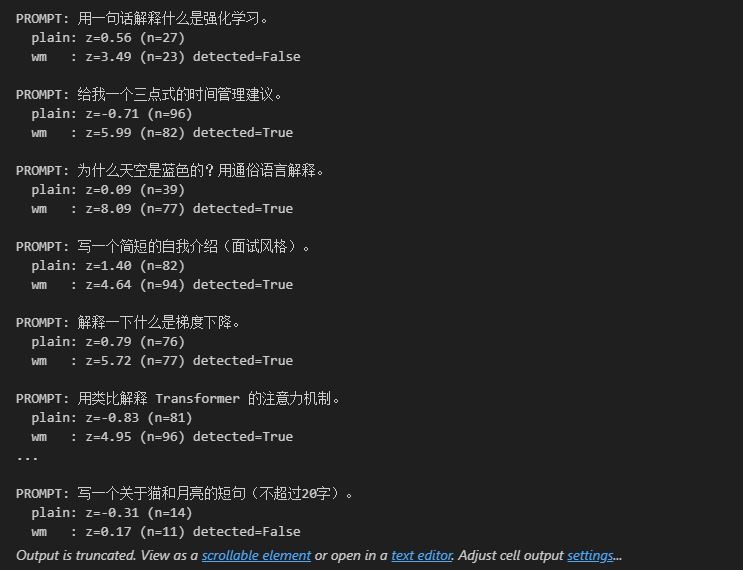

✅ (a) 误报很低

plain 的 z 基本在 [-1, +1.4] 左右，没有出现大于 4 的（否则就是误报）。
这说明阈值 4.0 足够严格，不会冤枉正常文本。

✅ (b) 水印检出率很高（除了短文本）

wm 里大多数都 z > 4，并且 detected=True：

5.99 / 8.09 / 4.64 / 5.72 / 4.95 / 4.28 / 4.93 都非常明确。

## 9. 汇总指标：False Positive（误报）与 True Positive（检出）

- **False positives**：plain 被判为有水印的次数（越低越好）  
- **True positives**：wm 被判为有水印的次数（越高越好）  

记住：这是一个典型 trade-off：  
- 阈值高 → 误报低，但漏报多  
- 阈值低 → 检出高，但误报可能上升



In [9]:
plain_fp = sum(1 for r in results if r["plain_z"] > Z_THRESHOLD)
wm_tp = sum(1 for r in results if r["wm_detected"])
print("Z_THRESHOLD =", Z_THRESHOLD)
print("False positives on plain:", plain_fp, "/", len(results))
print("True positives on watermarked:", wm_tp, "/", len(results))


Z_THRESHOLD = 4.0
False positives on plain: 0 / 10
True positives on watermarked: 7 / 10


## 10. 由浅入深：为什么短文本更容易“检测失败”？

你之前看到的现象：  
- 某些 wm 的 `z` 值只有 2~3，没过阈值 → `detected=False`  
主要原因通常是 **n 太小**（文本太短），统计不稳定。

下面我们打印出 `n` 很小的样本：



In [10]:
# 找到 wm_n 较小的例子
small = sorted(results, key=lambda x: x["wm_n"])[:5]
for r in small:
    print("\nPROMPT:", r["prompt"])
    print("  wm_n:", r["wm_n"], "wm_z:", round(r["wm_z"], 2))
    print("  wm_text:", r["wm_text"][:80].replace("\n"," ") + ("..." if len(r["wm_text"])>80 else ""))



PROMPT: 写一个关于猫和月亮的短句（不超过20字）。
  wm_n: 11 wm_z: 0.17
  wm_text: 猫喜欢在明亮的月光下嬉戏。

PROMPT: 写一句鼓励学习的中文标语。
  wm_n: 12 wm_z: 2.0
  wm_text: "学习是人生的阶梯，勤奋是人生的基石。"

PROMPT: 用一句话解释什么是强化学习。
  wm_n: 23 wm_z: 3.49
  wm_text: 强化学习是一种机器学习方法，它通过模拟环境中，让机器不断尝试行为，以找到最佳结果。

PROMPT: 用两句话解释什么是 overfitting。
  wm_n: 69 wm_z: 4.93
  wm_text: 过度fitting是指在训练数据上使用了过拟合的模型，以至于它在新的或未知的数据上表现良好，而对训练数据的拟合程度不高。当模型在训练数据上的泛化能力不强时，它可...

PROMPT: 给一个健康饮食的一日计划（简短）。
  wm_n: 70 wm_z: 4.28
  wm_text: 早餐：燕麦粥+新鲜水果+低脂牛奶 上午：吃一份全麦面包+一份新鲜水果+一份低脂牛奶 中午：吃一份炒蔬菜+一份烤肉 下午：吃一份蒸鱼+一份全麦面包+一份新鲜水果 ...


## 解释

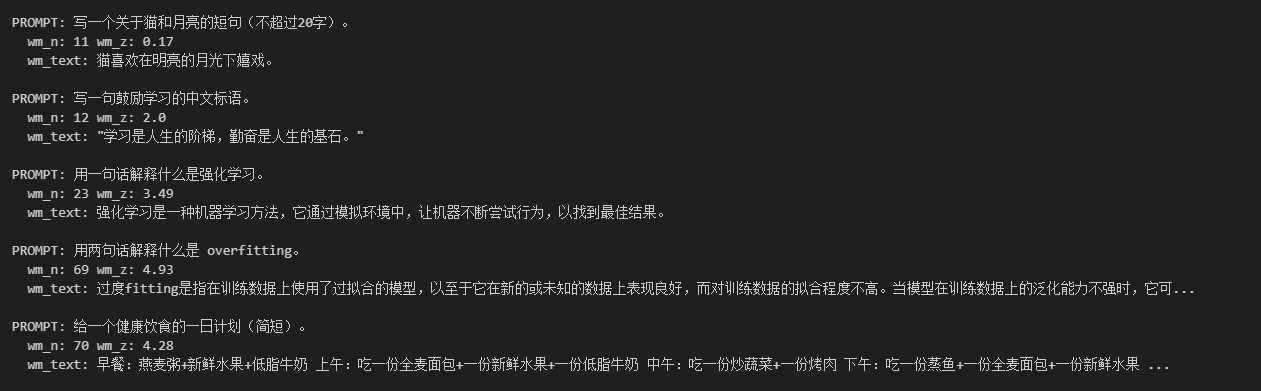

短文本（n≈10–20）水印信号很难累积到足够显著，因此容易漏检；长一点的文本（n≈70）统计更稳定，z-score 更容易超过阈值，从而可靠检出水印

## 11. 攻击/破坏演示：截断与噪声

水印不是万能的：  
- **TRUNC（截断）**：把文本变短，n 下降 → z 下降  
- **NOISY（噪声替换）**：改写/编辑会破坏绿色命中规律 → z 下降  

我们做两个最轻量的破坏方式：
1) 截断到 40%  
2) 随机替换 10% token（模拟改写噪声）



In [11]:
def truncate_ids(gen_ids, keep_ratio=0.4):
    k = max(1, int(len(gen_ids) * keep_ratio))
    return gen_ids[:k]

def random_replace_ids(gen_ids, replace_ratio=0.1):
    if len(gen_ids) == 0:
        return gen_ids
    vocab = tokenizer.vocab_size
    out = gen_ids[:]
    m = max(1, int(len(out) * replace_ratio))
    idxs = random.sample(range(len(out)), k=m)
    for i in idxs:
        out[i] = random.randrange(0, vocab)
    return out

# 挑一个样本演示（默认用第 0 条 prompt）
p = PROMPTS[0]
pid, gid, txt = generate_tokens(
    p, watermark=True, wm_key=WM_KEY, wm_gamma=WM_GAMMA, wm_delta=WM_DELTA,
    max_new_tokens=120, temperature=0.8, top_p=0.9, do_sample=True
)

det_clean = detect_watermark(pid, gid, wm_key=WM_KEY, wm_gamma=WM_GAMMA)
det_trunc = detect_watermark(pid, truncate_ids(gid, 0.4), wm_key=WM_KEY, wm_gamma=WM_GAMMA)
det_noisy = detect_watermark(pid, random_replace_ids(gid, 0.1), wm_key=WM_KEY, wm_gamma=WM_GAMMA)

print("CLEAN z=%.2f n=%d" % (det_clean["z"], det_clean["n"]))
print("TRUNC z=%.2f n=%d" % (det_trunc["z"], det_trunc["n"]))
print("NOISY z=%.2f n=%d" % (det_noisy["z"], det_noisy["n"]))


CLEAN z=4.45 n=23
TRUNC z=2.12 n=9
NOISY z=2.53 n=23


## 解释

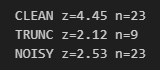

CLEAN 表示原始带水印文本：z=4.45 超过阈值（如 4.0），说明绿色 token 命中率显著偏高，水印可被检出。

TRUNC 是截断后文本变短（n=9），样本量太小导致统计不稳定，z 明显下降到 2.12，容易漏检。

NOISY 是加入噪声/改写后虽然长度不变（n=23），但水印模式被破坏，z 从 4.45 降到 2.53，同样会削弱检测效果。

## 12. 参数调试实验（更深一步）：delta / 文本长度 对检出率的影响

目标：清楚这些“可控旋钮”：
- `WM_DELTA` ↑ → 水印更强（TP ↑，可能影响流畅度）  
- `max_new_tokens` ↑ → 样本 n 更大（TP ↑，统计更稳）  
- `Z_THRESHOLD` ↓ → 判定更宽松（TP ↑，FP 可能 ↑）

下面给一个小网格实验：固定 `gamma=0.25`，扫 `delta` 与 `max_new_tokens`。

> 注意：扫参会多跑几次模型，若你在 CPU 上会慢；必要时减少组合数量。



In [12]:
def run_eval(max_new_tokens=96, wm_delta=2.0, z_thr=4.0, prompts=PROMPTS):
    cfg = dict(max_new_tokens=max_new_tokens, temperature=0.8, top_p=0.9, do_sample=True)
    plain_fp = 0
    wm_tp = 0
    for p in prompts:
        pid0, gid0, _ = generate_tokens(p, watermark=False, **cfg)
        det0 = detect_watermark(pid0, gid0, wm_key=WM_KEY, wm_gamma=WM_GAMMA)
        plain_fp += int(det0["z"] > z_thr)

        pid1, gid1, _ = generate_tokens(p, watermark=True, wm_key=WM_KEY, wm_gamma=WM_GAMMA, wm_delta=wm_delta, **cfg)
        det1 = detect_watermark(pid1, gid1, wm_key=WM_KEY, wm_gamma=WM_GAMMA)
        wm_tp += int(det1["z"] > z_thr)

    return plain_fp, wm_tp

deltas = [1.5, 2.0, 2.5]
lengths = [64, 96, 160]
z_thr = 4.0

grid = []
for L in lengths:
    for d in deltas:
        fp, tp = run_eval(max_new_tokens=L, wm_delta=d, z_thr=z_thr)
        grid.append((L, d, fp, tp))

print("Z_THRESHOLD =", z_thr)
print("max_new_tokens | delta | FP_plain/10 | TP_wm/10")
for L, d, fp, tp in grid:
    print(f"{L:>13} | {d:>5} | {fp:>10}/10 | {tp:>7}/10")


Z_THRESHOLD = 4.0
max_new_tokens | delta | FP_plain/10 | TP_wm/10
           64 |   1.5 |          0/10 |       4/10
           64 |   2.0 |          0/10 |       5/10
           64 |   2.5 |          0/10 |       7/10
           96 |   1.5 |          0/10 |       3/10
           96 |   2.0 |          0/10 |       7/10
           96 |   2.5 |          0/10 |       7/10
          160 |   1.5 |          0/10 |       3/10
          160 |   2.0 |          0/10 |       5/10
          160 |   2.5 |          0/10 |       8/10


## 结果加解释
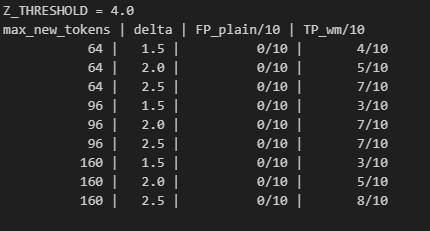

这张表说明在阈值固定为 Z_THRESHOLD=4.0 时，plain 基本不会被误报（FP 始终 0/10），检测非常“保守”。

与此同时，水印检出率（TP）主要随 delta 增大而上升：同样长度下，delta 从 1.5→2.5，TP 从 3–4/10 提升到 7–8/10。

max_new_tokens 变长不一定单调提升 TP（因为生成会提前停或随机性影响），但在 delta=2.5 时，较长输出（160）能达到最高的 8/10 检出率。

## 13. 工程落地提示

1. **密钥（WM_KEY）要保密**：  
   - 服务端持有密钥；检测端在需要溯源时调用（或授权第三方检测）。  

2. **阈值是策略选择**：  
   - 高阈值：几乎不误报，但可能漏掉短文本/被编辑文本。  
   - 低阈值：更敏感，但可能出现误报，需要配合更多证据。  

3. **攻击/鲁棒性**：  
   - 截断、改写、翻译、同义替换都会削弱检测。  
   - 实际系统要做更系统的对抗评估，并搭配其它治理手段。  

